# Which NBA Superstar Delivers in the Clutch? (last 5 playoff seasons)

This notebook answers one question: **of the league's #1 / #2 options, which
superstar actually delivers when the pressure is highest?** It pulls NBA
**playoff** data via [`nba_api`](https://github.com/swar/nba_api), restricts the
field to each playoff team's **primary options** (not role players), computes
clutch-time delivery metrics across the **2021-22 → 2025-26** playoffs, and blends
them into a weighted **Composite Clutch Score**.

**Two definitions drive everything:**
- **Clutch** = last 5 minutes of a game with the score within 5 points (the NBA's
  standard definition).
- **Eligible (a "superstar / #1 option")** = one of the top **2** players on a
  playoff team that season, ranked by a blend of **usage rate** and **points per
  game**. This deliberately filters out efficient low-volume role players — a
  catch-and-shoot specialist is not what we mean by "clutch superstar."

### Methodology at a glance
1. **Collect** per-season playoff clutch stats (Base / Advanced / Scoring measure
   types), full-season general stats, and player game logs. Everything is cached
   to `data/*.csv` so re-runs don't re-hit the API.
2. **Filter to superstars** — keep only each team's top-2 usage+scoring options per
   season; everyone else is dropped before scoring.
3. **Compute** per-player clutch-delivery metrics, *stacked across every season a
   player qualified as a top option* (multi-year samples stabilize the rates).
4. **Score** with a delivery-weighted composite (scoring volume, efficiency,
   usage, and elimination-game play lead; team-driven +/- and win-rate are
   down-weighted), normalized to a robust 0-100 percentile scale. A **capped**
   sample-size multiplier keeps deep playoff runs from winning on raw game-count
   alone, while still demanding a minimum sample.
5. **Visualize** the leaders, the efficiency/impact landscape, elimination-game
   specialists, the most consistent players, and year-over-year trends.
6. **Validate** the ranking with *multiple models* — PCA, KMeans archetypes, a
   regression on winning, and an ensemble with a method-agreement check — so the
   result doesn't hinge on one set of hand-picked weights. Biases are catalogued
   in a dedicated *Limitations* section.

> **Data note:** the NBA stats API can occasionally rate-limit or block requests.
> The notebook sleeps between calls and caches every response. If a season has no
> playoff data yet (e.g. an in-progress season), it is skipped gracefully.

## 0. Environment setup

Install the required packages. If they're already in your environment this is a
no-op. (Uncomment to run.)

In [1]:
# Run once if needed -- installs into the active environment.
# %pip install nba_api pandas numpy matplotlib seaborn scikit-learn

## Cell 1 — Imports & configuration

All knobs live here: the seasons to analyze, the clutch definition, the composite
**weights**, and the **minimum clutch-minutes** threshold. Adjust and re-run the
notebook to change the analysis.

In [2]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import silhouette_score

from nba_api.stats.endpoints import (
    leaguedashplayerclutch,
    leaguedashplayerstats,
    leaguegamelog,
)

warnings.filterwarnings("ignore")

# ----------------------------- CONFIG --------------------------------------
SEASONS = ["2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
SEASON_TYPE = "Playoffs"

# Clutch definition: last 5 minutes, score within 5 points.
CLUTCH_TIME = "Last 5 Minutes"
AHEAD_BEHIND = "Ahead or Behind"
POINT_DIFF = 5

# ---- Superstar eligibility -------------------------------------------------
# This model judges ONLY each team's primary options, not role players. For every
# playoff team in every season we keep the top STARS_PER_TEAM players by a blend of
# full-playoff usage rate and points per game (i.e. "who the offense runs through").
STARS_PER_TEAM = 2
STAR_MIN_GP = 2          # a star must have actually played this many playoff games that year
USG_SCORING_BLEND = 0.5  # eligibility blend: 0 = pure scoring, 1 = pure usage, 0.5 = even

# Sample-size handling (per-opportunity + cap, so deep playoff runs don't win on
# raw accumulation -- rate stats + a capped confidence multiplier).
MIN_CLUTCH_MINUTES = 50        # hard filter: drop players below this many total clutch minutes
SAMPLE_FULL_CONFIDENCE = 150   # minutes at which the sample-size penalty reaches 1.0 (no penalty)

# Composite clutch-score weights (must sum to 1.0). Tweak freely.
# Tuned for a SUPERSTAR-DELIVERY model: reward carrying the scoring load efficiently
# under pressure (PPG + usage + TS% + elimination), and de-emphasize the team-driven
# metrics (+/- and win rate) that previously inflated low-volume role players.
WEIGHTS = {
    "ppg":         0.20,   # clutch scoring VOLUME -- did they deliver buckets?
    "ts":          0.20,   # clutch true shooting % -- efficiency
    "elimination": 0.20,   # Game 6/7 delivery -- performance at maximum pressure
    "usage":       0.15,   # clutch usage rate -- shouldering the load
    "plus_minus":  0.10,   # clutch +/- (team-influenced -> down-weighted)
    "consistency": 0.10,   # low game-to-game variance
    "win_rate":    0.05,   # win rate in clutch games (team-influenced -> down-weighted)
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, "WEIGHTS must sum to 1.0"

# Be polite to the API.
SLEEP_SECONDS = 1.5
REQUEST_TIMEOUT = 60

# Caching.
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Plot styling.
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# Footnote stamped on every chart for a presentation-ready look.
SOURCE = ("Source: NBA Stats API via nba_api  ·  Clutch = last 5 min, score within 5  ·  "
          "Playoffs 2021-22 → 2025-26")


def stamp(fig):
    fig.text(0.99, -0.02, SOURCE, ha="right", va="top", fontsize=8,
             color="grey", style="italic")


print("Config loaded.")
print(f"Seasons: {SEASONS}")
print(f"Eligibility: top {STARS_PER_TEAM} usage+scoring options per playoff team per season")
print(f"Clutch: {CLUTCH_TIME}, within {POINT_DIFF} pts | min clutch minutes: {MIN_CLUTCH_MINUTES}")
print(f"Weights: {WEIGHTS}")

Config loaded.
Seasons: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Eligibility: top 2 usage+scoring options per playoff team per season
Clutch: Last 5 Minutes, within 5 pts | min clutch minutes: 50
Weights: {'ppg': 0.2, 'ts': 0.2, 'elimination': 0.2, 'usage': 0.15, 'plus_minus': 0.1, 'consistency': 0.1, 'win_rate': 0.05}


## Cell 2 — Data fetching & caching functions

Every API response is written to `data/<name>.csv`. On subsequent runs the CSV is
loaded instead of re-calling the API. A 1.5s sleep is inserted **only when we
actually hit the network**, to avoid rate limiting.

In [3]:
def _cache_path(name):
    return os.path.join(DATA_DIR, f"{name}.csv")


def cached_fetch(name, fetch_fn):
    """Return a cached CSV if present, otherwise call `fetch_fn`, cache, and return it.

    `fetch_fn` must return a pandas DataFrame. Network calls sleep afterward.
    """
    path = _cache_path(name)
    if os.path.exists(path):
        return pd.read_csv(path)

    print(f"  -> fetching '{name}' from NBA API ...", flush=True)
    df = fetch_fn()
    df.to_csv(path, index=False)
    time.sleep(SLEEP_SECONDS)  # only sleep on a real network hit
    return df


def fetch_clutch(season, measure_type):
    """Player clutch stats for a season. measure_type in {Base, Advanced, Scoring}."""
    name = f"clutch_{measure_type.lower()}_{season}"

    def _fetch():
        ep = leaguedashplayerclutch.LeagueDashPlayerClutch(
            season=season,
            season_type_all_star=SEASON_TYPE,
            clutch_time=CLUTCH_TIME,
            ahead_behind=AHEAD_BEHIND,
            point_diff=POINT_DIFF,
            measure_type_detailed_defense=measure_type,
            per_mode_detailed="PerGame",
            timeout=REQUEST_TIMEOUT,
        )
        return ep.get_data_frames()[0]

    return cached_fetch(name, _fetch)


def fetch_general(season, measure_type):
    """Full-season (non-clutch) player stats. measure_type in {Base, Advanced}."""
    name = f"general_{measure_type.lower()}_{season}"

    def _fetch():
        ep = leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            season_type_all_star=SEASON_TYPE,
            measure_type_detailed_defense=measure_type,
            per_mode_detailed="PerGame",
            timeout=REQUEST_TIMEOUT,
        )
        return ep.get_data_frames()[0]

    return cached_fetch(name, _fetch)


def fetch_gamelog(season):
    """Per-player playoff game logs (used for elimination games + consistency)."""
    name = f"gamelog_{season}"

    def _fetch():
        ep = leaguegamelog.LeagueGameLog(
            season=season,
            season_type_all_star=SEASON_TYPE,
            player_or_team_abbreviation="P",
            timeout=REQUEST_TIMEOUT,
        )
        return ep.get_data_frames()[0]

    return cached_fetch(name, _fetch)


print("Fetch helpers ready.")

Fetch helpers ready.


## Cell 3 — Data collection, cleaning & merging

We loop over every season, pulling the three clutch measure types, the general
stats, and the game logs (with progress messages). Empty seasons (e.g. a playoff
run that hasn't happened yet) are skipped. We then merge the three clutch tables
into one **player-season** clutch table.

In [4]:
clutch_frames, general_frames, gamelog_frames = [], [], []

for season in SEASONS:
    print(f"Season {season} ...", flush=True)
    try:
        base = fetch_clutch(season, "Base")
        adv = fetch_clutch(season, "Advanced")
        scoring = fetch_clutch(season, "Scoring")
        gen_base = fetch_general(season, "Base")
        gen_adv = fetch_general(season, "Advanced")
        glog = fetch_gamelog(season)
    except Exception as exc:  # network / no-data resilience
        print(f"  !! skipping {season}: {exc}")
        continue

    if base.empty or len(base) == 0:
        print(f"  (no playoff clutch data for {season} -- skipping)")
        continue

    # --- clutch base columns ---
    base_cols = ["PLAYER_ID", "PLAYER_NAME", "TEAM_ABBREVIATION", "GP", "W", "L",
                 "MIN", "PTS", "PLUS_MINUS", "FGM", "FGA", "FTM", "FTA", "FT_PCT"]
    b = base[base_cols].copy()

    # --- clutch advanced columns (TS%, usage) ---
    a = adv[["PLAYER_ID", "TS_PCT", "USG_PCT"]].copy()

    # --- clutch scoring columns (assisted / unassisted) ---
    s = scoring[["PLAYER_ID", "PCT_AST_FGM", "PCT_UAST_FGM"]].copy()

    merged = b.merge(a, on="PLAYER_ID", how="left").merge(s, on="PLAYER_ID", how="left")
    merged["SEASON"] = season
    clutch_frames.append(merged)

    # full-season general context -- also drives the superstar eligibility filter
    # (need team, games, minutes, scoring, and usage to pick each team's top options).
    g = gen_base[["PLAYER_ID", "PLAYER_NAME", "TEAM_ABBREVIATION", "GP", "MIN", "PTS"]].rename(
        columns={"TEAM_ABBREVIATION": "TEAM", "GP": "SEASON_GP", "MIN": "SEASON_MIN",
                 "PTS": "SEASON_PPG"})
    ga = gen_adv[["PLAYER_ID", "TS_PCT", "USG_PCT"]].rename(
        columns={"TS_PCT": "SEASON_TS_PCT", "USG_PCT": "SEASON_USG_PCT"})
    gen = g.merge(ga, on="PLAYER_ID", how="left")
    gen["SEASON"] = season
    general_frames.append(gen)

    glog = glog.copy()
    glog["SEASON"] = season
    gamelog_frames.append(glog)
    print(f"  ok: {len(merged)} clutch players, {len(glog)} game-log rows")

clutch = pd.concat(clutch_frames, ignore_index=True) if clutch_frames else pd.DataFrame()
general = pd.concat(general_frames, ignore_index=True) if general_frames else pd.DataFrame()
gamelogs = pd.concat(gamelog_frames, ignore_index=True) if gamelog_frames else pd.DataFrame()

assert not clutch.empty, "No clutch data collected -- check API access / cached CSVs."

# Per-season *totals* derived from per-game values (MIN/PTS etc. are per-game).
clutch["MIN_TOTAL"] = clutch["MIN"] * clutch["GP"]
clutch["FTM_TOTAL"] = clutch["FTM"] * clutch["GP"]
clutch["FTA_TOTAL"] = clutch["FTA"] * clutch["GP"]
clutch["FGM_TOTAL"] = clutch["FGM"] * clutch["GP"]

print(f"\nCollected {clutch['PLAYER_ID'].nunique()} unique players across "
      f"{clutch['SEASON'].nunique()} seasons.")
clutch.head()

Season 2021-22 ...


  ok: 136 clutch players, 1892 game-log rows
Season 2022-23 ...


  ok: 131 clutch players, 1728 game-log rows
Season 2023-24 ...


  ok: 119 clutch players, 1685 game-log rows
Season 2024-25 ...


  ok: 131 clutch players, 1804 game-log rows
Season 2025-26 ...


  ok: 133 clutch players, 1921 game-log rows

Collected 324 unique players across 5 seasons.


,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,GP,W,L,MIN,PTS,PLUS_MINUS,FGM,...,FT_PCT,TS_PCT,USG_PCT,PCT_AST_FGM,PCT_UAST_FGM,SEASON,MIN_TOTAL,FTM_TOTAL,FTA_TOTAL,FGM_TOTAL
0,203932,Aaron Gordon,DEN,3,1,2,4.6,1.3,-3.7,0.0,...,1.0,0.725,0.138,0.00,0.00,2021-22,13.8,3.9,3.9,0.0
1,201143,Al Horford,BOS,12,7,5,2.6,0.9,0.0,0.4,...,0.0,0.423,0.178,0.40,0.60,2021-22,31.2,0.0,0.0,4.8
2,1627936,Alex Caruso,CHI,2,1,1,2.9,1.0,0.0,0.5,...,0.0,0.500,0.188,1.00,0.00,2021-22,5.8,0.0,0.0,1.0
3,2738,Andre Iguodala,GSW,1,1,0,1.2,0.0,-4.0,0.0,...,0.0,0.000,0.000,0.00,0.00,2021-22,1.2,0.0,0.0,0.0
4,203952,Andrew Wiggins,GSW,9,6,3,3.3,1.3,2.6,0.4,...,1.0,0.530,0.154,0.75,0.25,2021-22,29.7,2.7,2.7,3.6


## Cell 3b — Superstar eligibility: keep only each team's top-2 options

This is what makes the model about **superstars, not role players**. For every
**(team, season)** we rank players by a blend of full-playoff **usage rate** and
**points per game** — the two best signals for "the offense runs through this
player" — and keep only the top `STARS_PER_TEAM` (default 2). A player is then
analyzed *only in the seasons where they were a top option for their team*, and
those qualifying seasons **stack** across the five years into one body of work.

**Why a blend?** Usage alone can flag a high-turnover guard; scoring alone can flag
an empty-calories chucker. Averaging the two percentiles captures genuine primary
options. **Why per-season?** A player who was a #1 option in 2021 but a role player
by 2025 should only earn credit for the years he actually led a team.

In [5]:
elig = general.dropna(subset=["SEASON_USG_PCT", "SEASON_PPG"]).copy()
elig = elig[elig["SEASON_GP"] >= STAR_MIN_GP]

# Percentile of usage and scoring *within each season*, then blend them.
elig["usg_pctile"] = elig.groupby("SEASON")["SEASON_USG_PCT"].rank(pct=True)
elig["ppg_pctile"] = elig.groupby("SEASON")["SEASON_PPG"].rank(pct=True)
elig["star_blend"] = (USG_SCORING_BLEND * elig["usg_pctile"]
                      + (1 - USG_SCORING_BLEND) * elig["ppg_pctile"])

# Top-N per (season, team) by the blend = that team's primary options that year.
elig["team_rank"] = (elig.groupby(["SEASON", "TEAM"])["star_blend"]
                     .rank(ascending=False, method="first"))
stars = elig[elig["team_rank"] <= STARS_PER_TEAM].copy()
eligible_keys = set(zip(stars["PLAYER_ID"], stars["SEASON"]))

# Restrict the clutch table to eligible star-seasons only.
before_rows, before_players = len(clutch), clutch["PLAYER_ID"].nunique()
clutch["KEY"] = list(zip(clutch["PLAYER_ID"], clutch["SEASON"]))
clutch = clutch[clutch["KEY"].isin(eligible_keys)].drop(columns="KEY").reset_index(drop=True)

print(f"Selected {len(eligible_keys)} star-seasons "
      f"(top {STARS_PER_TEAM} per team x {stars['SEASON'].nunique()} seasons).")
print(f"Clutch rows: {before_rows} -> {len(clutch)} | "
      f"unique players: {before_players} -> {clutch['PLAYER_ID'].nunique()}")
latest = stars["SEASON"].max()
print(f"\nExample: {latest} eligible stars by team (blend of usage & scoring) --")
ex = (stars[stars["SEASON"] == latest]
      .sort_values(["TEAM", "team_rank"])[["TEAM", "PLAYER_NAME", "SEASON_PPG",
                                           "SEASON_USG_PCT", "star_blend"]])
print(ex.round(3).head(16).to_string(index=False))

Selected 160 star-seasons (top 2 per team x 5 seasons).
Clutch rows: 650 -> 154 | unique players: 324 -> 72

Example: 2025-26 eligible stars by team (blend of usage & scoring) --
TEAM      PLAYER_NAME  SEASON_PPG  SEASON_USG_PCT  star_blend
 ATL      CJ McCollum        19.2           0.289       0.915
 ATL    Jalen Johnson        19.5           0.247       0.881
 BOS     Jaylen Brown        25.7           0.325       0.979
 BOS     Jayson Tatum        23.3           0.262       0.913
 CLE Donovan Mitchell        26.0           0.306       0.972
 CLE     James Harden        19.2           0.246       0.873
 DEN     Nikola Jokić        25.8           0.295       0.964
 DEN     Jamal Murray        23.7           0.285       0.939
 DET  Cade Cunningham        28.1           0.315       0.987
 DET    Tobias Harris        18.1           0.228       0.840
 HOU   Alperen Sengun        20.3           0.247       0.887
 HOU    Amen Thompson        19.2           0.197       0.790
 LAL     LeBron

## Cell 4 — Per-player metric computation

We aggregate the per-season clutch rows into one **career-clutch** row per player
(weighting rate stats appropriately — TS%/usage by clutch minutes, free-throw % by
attempts, per-game stats by games played). We then derive two metrics that need
play-by-game data from the **game logs**:

- **Elimination performance** — average [Game Score](https://www.basketball-reference.com/about/glossary.html)
  in Game 6 & Game 7 of a series, and how much it *outperforms the player's
  non-elimination playoff baseline*. (We exclude the G6/7 games from the baseline
  so a player isn't being compared against himself.) Game numbers are
  reconstructed by ordering each series' games by date.
- **Consistency** — the coefficient of variation (CV = std / mean) of per-game
  points across all playoff games. Lower CV → more consistent. We convert it to a
  0-1 *consistency* value as `1 / (1 + CV)`.

> *Practical note:* a true per-game **clutch-only** Game Score isn't exposed by the
> API at scale, so elimination performance uses full-game box-score Game Score in
> Game 6/7 — the high-leverage, win-or-go-home games. This is documented and
> intentional.

In [6]:
# ---- 4a. Career-clutch aggregation (weighted) -----------------------------
def _wavg(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])


def aggregate_player(grp):
    gp = grp["GP"].sum()
    w, l = grp["W"].sum(), grp["L"].sum()
    min_total = grp["MIN_TOTAL"].sum()
    fta_total = grp["FTA_TOTAL"].sum()
    fgm_total = grp["FGM_TOTAL"].sum()
    uast = _wavg(grp["PCT_UAST_FGM"], grp["FGM_TOTAL"])  # fraction of makes unassisted
    ast = _wavg(grp["PCT_AST_FGM"], grp["FGM_TOTAL"])    # fraction of makes assisted
    return pd.Series({
        "PLAYER_NAME": grp["PLAYER_NAME"].iloc[-1],
        "TEAM": grp["TEAM_ABBREVIATION"].iloc[-1],
        "seasons_played": grp["SEASON"].nunique(),
        "clutch_gp": gp,
        "clutch_min_total": min_total,
        "clutch_ppg": _wavg(grp["PTS"], grp["GP"]),
        "clutch_plus_minus": _wavg(grp["PLUS_MINUS"], grp["GP"]),
        "clutch_ts": _wavg(grp["TS_PCT"], grp["MIN_TOTAL"]),
        "clutch_usg": _wavg(grp["USG_PCT"], grp["MIN_TOTAL"]),
        "clutch_ft_pct": (grp["FTM_TOTAL"].sum() / fta_total) if fta_total > 0 else np.nan,
        "pct_unassisted": uast,
        "pct_assisted": ast,
        # unassisted-to-assisted ratio (>1 == more self-created looks in the clutch)
        "uast_to_ast_ratio": (uast / ast) if (ast and ast > 0) else np.nan,
        "win_rate_clutch": (w / (w + l)) if (w + l) > 0 else np.nan,
    })


career = clutch.groupby("PLAYER_ID").apply(aggregate_player).reset_index()
print(f"Aggregated {len(career)} players.")

# ---- 4b. Elimination + consistency from game logs -------------------------
def game_score(df):
    """Hollinger Game Score."""
    return (df["PTS"] + 0.4 * df["FGM"] - 0.7 * df["FGA"]
            - 0.4 * (df["FTA"] - df["FTM"]) + 0.7 * df["OREB"] + 0.3 * df["DREB"]
            + df["STL"] + 0.7 * df["AST"] + 0.7 * df["BLK"] - 0.4 * df["PF"] - df["TOV"])


def series_key(matchup):
    """Normalize 'LAL vs. DEN' / 'LAL @ DEN' to an order-independent pair key."""
    sep = " vs. " if " vs. " in matchup else " @ "
    a, b = matchup.split(sep)
    return "-".join(sorted([a.strip(), b.strip()]))


gl = gamelogs.copy()
gl["GAME_DATE"] = pd.to_datetime(gl["GAME_DATE"])
gl["SERIES"] = gl["MATCHUP"].apply(series_key)
gl["GAME_SCORE"] = game_score(gl)

# Reconstruct game number within each series (per season).
game_order = (gl[["SEASON", "SERIES", "GAME_ID", "GAME_DATE"]]
              .drop_duplicates()
              .sort_values(["SEASON", "SERIES", "GAME_DATE"]))
game_order["GAME_NUM"] = game_order.groupby(["SEASON", "SERIES"]).cumcount() + 1
gl = gl.merge(game_order[["SEASON", "SERIES", "GAME_ID", "GAME_NUM"]],
              on=["SEASON", "SERIES", "GAME_ID"], how="left")

# Elimination = Game 6 or Game 7 of a series (win-or-go-home pressure).
gl["IS_ELIM"] = gl["GAME_NUM"].isin([6, 7])

overall = gl.groupby("PLAYER_ID").agg(
    po_games=("GAME_ID", "nunique"),
    overall_gmsc=("GAME_SCORE", "mean"),
    pts_mean=("PTS", "mean"),
    pts_std=("PTS", "std"),
).reset_index()

# Baseline for the elimination delta = NON-elimination games only. Using the
# all-games average would put the very G6/7 games we're measuring *inside* the
# baseline, biasing the delta toward zero. We compare elim vs. non-elim instead.
non_elim = (gl[~gl["IS_ELIM"]].groupby("PLAYER_ID")
            .agg(non_elim_games=("GAME_ID", "nunique"),
                 non_elim_gmsc=("GAME_SCORE", "mean"))
            .reset_index())

elim = (gl[gl["IS_ELIM"]].groupby("PLAYER_ID")
        .agg(elim_games=("GAME_ID", "nunique"),
             elim_gmsc=("GAME_SCORE", "mean"),
             elim_pts=("PTS", "mean"))
        .reset_index())

logs = overall.merge(non_elim, on="PLAYER_ID", how="left").merge(elim, on="PLAYER_ID", how="left")
logs["elim_games"] = logs["elim_games"].fillna(0).astype(int)
# How much a player raises (or drops) their game in elimination games relative to
# their *non-elimination* playoff baseline (uncontaminated by the elim games).
logs["elim_delta"] = logs["elim_gmsc"] - logs["non_elim_gmsc"]
# Consistency: coefficient of variation of per-game points -> 0..1 (higher = steadier).
cv = logs["pts_std"] / logs["pts_mean"].replace(0, np.nan)
logs["pts_cv"] = cv
logs["consistency"] = 1.0 / (1.0 + cv)

metrics = career.merge(logs, on="PLAYER_ID", how="left")

# ---- 4c. Apply the minimum clutch-minutes filter --------------------------
before = len(metrics)
metrics = metrics[metrics["clutch_min_total"] >= MIN_CLUTCH_MINUTES].reset_index(drop=True)
print(f"Filtered to >= {MIN_CLUTCH_MINUTES} clutch minutes: "
      f"{len(metrics)} of {before} players remain.")
metrics.head()

Aggregated 72 players.


Filtered to >= 50 clutch minutes: 18 of 72 players remain.

,PLAYER_ID,PLAYER_NAME,TEAM,seasons_played,clutch_gp,clutch_min_total,clutch_ppg,clutch_plus_minus,clutch_ts,clutch_usg,...,pts_mean,pts_std,non_elim_games,non_elim_gmsc,elim_games,elim_gmsc,elim_pts,elim_delta,pts_cv,consistency
0,2544,LeBron James,LAL,4,17,70.6,2.282353,-0.923529,0.470443,0.314763,...,24.722222,5.521962,33.0,20.933333,3,23.100000,26.666667,2.166667,0.223360,0.817421
1,201935,James Harden,CLE,5,20,83.2,3.150000,-0.380000,0.629700,0.313909,...,19.425926,7.899371,43.0,15.909302,11,14.545455,15.636364,-1.363848,0.406641,0.710914
2,201939,Stephen Curry,GSW,3,18,65.7,3.866667,0.983333,0.562110,0.385548,...,27.418605,7.907900,36.0,19.394444,7,22.857143,32.142857,3.462698,0.288414,0.776148
3,202681,Kyrie Irving,DAL,2,14,52.5,2.485714,-1.007143,0.507703,0.289263,...,22.000000,9.436101,24.0,15.875000,2,16.750000,26.000000,0.875000,0.428914,0.699832
4,203954,Joel Embiid,PHI,4,12,60.3,2.250000,-0.166667,0.421149,0.268469,...,25.468750,8.428004,25.0,18.936000,7,19.300000,26.571429,0.364000,0.330915,0.751363


## Cell 5 — Composite Clutch Score

Each input metric is converted to an **outlier-robust 0-100 percentile score**
(ranked *within the superstar pool* — not min-max, see `normalize_100`), then
combined with the **delivery weights** from Cell 1: clutch **PPG (20%)**, **TS%
(20%)**, **elimination (20%)**, **usage (15%)**, plus the down-weighted, team-driven
**+/- (10%)**, **consistency (10%)** and **win-rate (5%)**. Adding scoring *volume*
and leaning on usage is the deliberate fix for the old model, where a low-volume
role player could top the board on efficiency alone.

A **capped sample-size multiplier** then shrinks scores for thin samples but stops
rewarding sheer accumulation past `SAMPLE_FULL_CONFIDENCE` minutes — so a star with
five deep playoff runs doesn't beat another on game-count alone:

```
penalty = sqrt( clip(clutch_min_total / SAMPLE_FULL_CONFIDENCE, 0, 1) )
composite = (weighted 0-100 score) * penalty
```

Metrics where missing data should be neutral (elimination delta, consistency) are
filled with the pool median before scoring.

In [7]:
# Weights are restated here for easy tweaking without scrolling back up.
# Delivery-weighted: scoring volume + efficiency + usage + elimination lead;
# team-driven +/- and win-rate are down-weighted.
WEIGHTS = {
    "ppg":         0.20,
    "ts":          0.20,
    "elimination": 0.20,
    "usage":       0.15,
    "plus_minus":  0.10,
    "consistency": 0.10,
    "win_rate":    0.05,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9


def normalize_100(series):
    """Outlier-robust 0-100 score via percentile rank.

    We deliberately avoid plain min-max scaling here: a single small-sample
    extreme (e.g. a 100%+ clutch TS on a handful of shots) would set the maximum
    and compress everyone else toward the bottom -- a real source of skew.
    Percentile ranking is robust to such outliers and is the standard approach
    for composite indices. NaNs are treated as neutral (median rank = 50).
    """
    s = series.astype(float)
    ranked = s.rank(pct=True, na_option="keep") * 100.0
    return ranked.fillna(50.0)


df = metrics.copy()

# Fill the play-by-game metrics' missing values with neutral (median) before scoring.
df["elim_delta_f"] = df["elim_delta"].fillna(df["elim_delta"].median())
df["consistency_f"] = df["consistency"].fillna(df["consistency"].median())

df["n_ppg"] = normalize_100(df["clutch_ppg"])
df["n_ts"] = normalize_100(df["clutch_ts"])
df["n_plus_minus"] = normalize_100(df["clutch_plus_minus"])
df["n_usage"] = normalize_100(df["clutch_usg"])
df["n_win_rate"] = normalize_100(df["win_rate_clutch"])
df["n_elimination"] = normalize_100(df["elim_delta_f"])
df["n_consistency"] = normalize_100(df["consistency_f"])

df["composite_raw"] = (
    WEIGHTS["ppg"]         * df["n_ppg"] +
    WEIGHTS["ts"]          * df["n_ts"] +
    WEIGHTS["elimination"] * df["n_elimination"] +
    WEIGHTS["usage"]       * df["n_usage"] +
    WEIGHTS["plus_minus"]  * df["n_plus_minus"] +
    WEIGHTS["consistency"] * df["n_consistency"] +
    WEIGHTS["win_rate"]    * df["n_win_rate"]
)

df["sample_penalty"] = np.sqrt(
    np.clip(df["clutch_min_total"] / SAMPLE_FULL_CONFIDENCE, 0, 1))
df["composite_score"] = df["composite_raw"] * df["sample_penalty"]

df = df.sort_values("composite_score", ascending=False).reset_index(drop=True)
df["rank"] = df.index + 1

print("Top 10 by Composite Clutch Score:\n")
print(df[["rank", "PLAYER_NAME", "TEAM", "composite_score", "clutch_ts",
          "clutch_plus_minus", "clutch_min_total"]].head(10).to_string(index=False))

Top 10 by Composite Clutch Score:

 rank             PLAYER_NAME TEAM  composite_score  clutch_ts  clutch_plus_minus  clutch_min_total
    1           Jalen Brunson  NYK        82.861533   0.559989           2.027500             149.3
    2 Shai Gilgeous-Alexander  OKC        61.158062   0.625421           1.272222              76.4
    3           Stephen Curry  GSW        56.713927   0.562110           0.983333              65.7
    4            Jayson Tatum  BOS        55.674662   0.576541           0.062857             118.5
    5            James Harden  CLE        46.237150   0.629700          -0.380000              83.2
    6            Nikola Jokić  DEN        46.133435   0.521810          -0.225806             107.7
    7            LeBron James  LAL        38.304542   0.470443          -0.923529              70.6
    8         Anthony Edwards  MIN        37.401154   0.551577           0.842308              86.8
    9        Donovan Mitchell  CLE        36.974315   0.452820   

## Cell 6 — Visualization 1: Top 20 most clutch players

**What it shows.** The headline ranking — the 20 highest **Composite Clutch
Scores**, drawn as a horizontal bar chart (longer bar = more clutch).

**How to read it.** Players are sorted top-to-bottom, #1 at the top. The number at
the end of each bar is the score on a **0-100 scale**, and bar color runs along the
*viridis* gradient purely to track rank (dark→bright as you climb). Because the
inputs were converted to **percentiles** before weighting, a score of, say, 70
roughly means "this player sits around the 70th percentile of the clutch pool once
all six factors are blended" — it is *relative to the other qualified players*, not
an absolute rating.

**The stat behind it.** Composite = weighted blend of seven percentile-scored
delivery metrics — clutch PPG (20%), TS% (20%), elimination uplift (20%), usage
(15%), +/- (10%), consistency (10%), and win-rate (5%) — then multiplied by a
**capped sample-size multiplier** (√ of clutch minutes up to the confidence cap).
The field is already restricted to each team's **top-2 usage+scoring options**, so
every name here is a genuine #1/#2 option; a player ranks highly by *delivering
buckets efficiently under pressure*, not by quietly converting a couple of open
looks.

**What to look for.** The gap between #1 and the pack (is there a clear-cut "most
clutch superstar," or a tight cluster?), and which teams place both stars. Treat
this as the domain-weighted view — the *Ensemble* column later shows who survives
when the weighting choice changes.

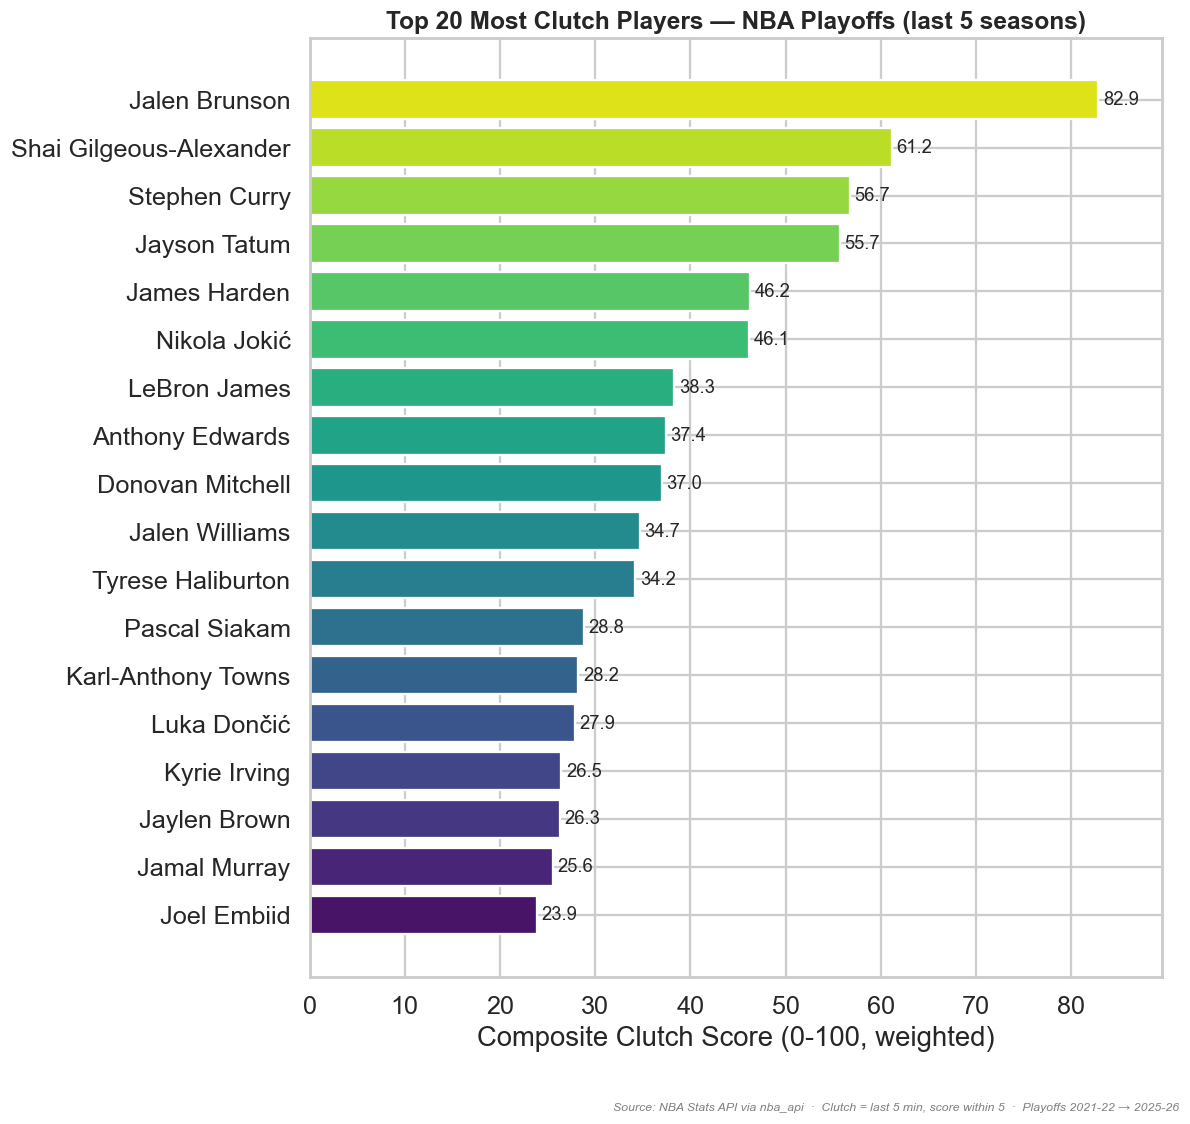

In [8]:
top20 = df.head(20).iloc[::-1]  # reverse so #1 is on top

fig, ax = plt.subplots(figsize=(11, 10))
colors = sns.color_palette("viridis", len(top20))
ax.barh(top20["PLAYER_NAME"], top20["composite_score"], color=colors)

for y, (val, team) in enumerate(zip(top20["composite_score"], top20["TEAM"])):
    ax.text(val + 0.5, y, f"{val:.1f}", va="center", fontsize=12)

ax.set_xlabel("Composite Clutch Score (0-100, weighted)")
ax.set_title("Top 20 Most Clutch Players — NBA Playoffs (last 5 seasons)",
             fontsize=16, weight="bold")
ax.margins(x=0.08)
stamp(fig)
plt.tight_layout()
plt.show()

## Cell 7 — Visualization 2: Clutch efficiency vs. impact

**What it shows.** Two of the most important clutch dimensions plotted against each
other, so you can see *style and value at once* rather than collapsing them into a
single number.

**How to read it — four visual channels:**
- **x-axis = clutch True Shooting %** — scoring *efficiency* (accounts for 2s, 3s,
  and free throws in one number). Further right = more efficient.
- **y-axis = clutch +/-** — the team's average net points while the player is on the
  floor in the clutch. Higher = bigger positive *impact*.
- **marker size = clutch usage rate** — bigger dot = more of the offense ran through
  that player in the clutch (i.e. how much *load* they carried).
- **marker color = composite score** — brighter = higher overall clutch rank.

The two dashed lines are reference points: the horizontal line is **+/- = 0**
(break-even impact) and the vertical line is the **median clutch TS%** of the pool.
They split the plot into four quadrants.

**What to look for.** The **upper-right quadrant** (efficient *and* positive impact)
is the elite zone — and a *large, bright* dot there is the ideal: a high-usage star
who stays efficient and lifts the team under pressure. The lower-right (efficient
but negative +/-) often flags low-usage role players; the upper-left (positive
impact, below-median efficiency) can flag volume creators whose value comes from
gravity/playmaking rather than pure scoring efficiency. **Caveat:** +/- is
team/lineup-dependent (see *Limitations*), so read the y-axis as a team-context
signal, not isolated individual value.

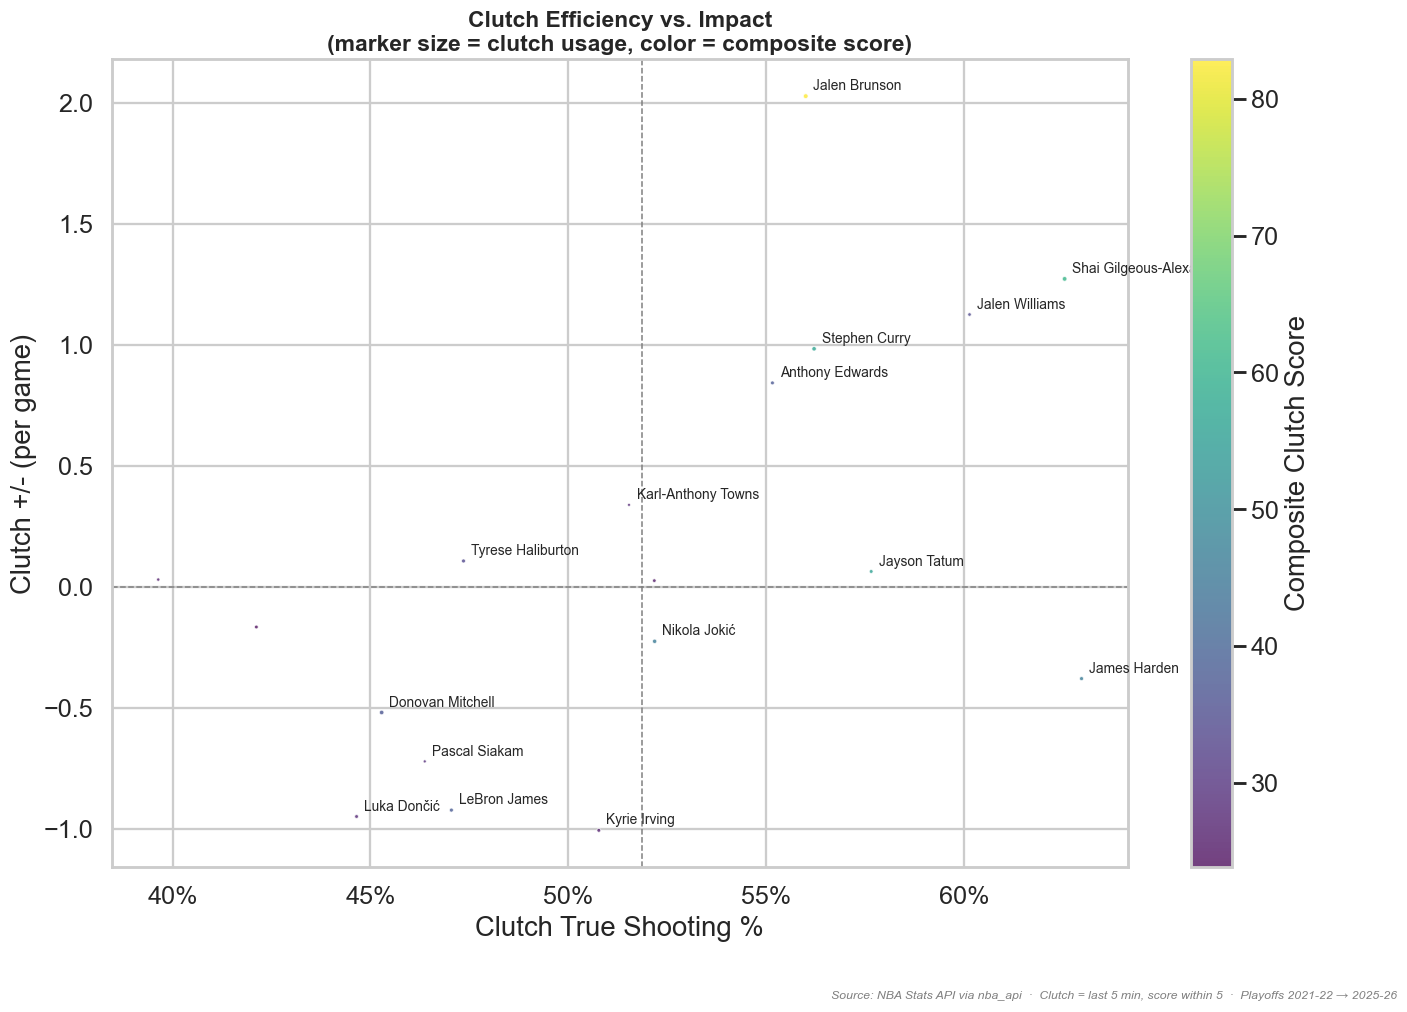

In [9]:
plot_df = df[df["clutch_ts"].notna() & df["clutch_plus_minus"].notna()].copy()

fig, ax = plt.subplots(figsize=(13, 9))
sizes = (plot_df["clutch_usg"].fillna(plot_df["clutch_usg"].median())) * 22
sc = ax.scatter(plot_df["clutch_ts"] * 100, plot_df["clutch_plus_minus"],
                s=sizes, c=plot_df["composite_score"], cmap="viridis",
                alpha=0.75, edgecolor="white", linewidth=0.6)

# Label the most notable players (top composite scorers).
for _, r in plot_df.head(15).iterrows():
    ax.annotate(r["PLAYER_NAME"], (r["clutch_ts"] * 100, r["clutch_plus_minus"]),
                fontsize=9, xytext=(5, 4), textcoords="offset points")

ax.axhline(0, color="grey", lw=1, ls="--")
ax.axvline(plot_df["clutch_ts"].median() * 100, color="grey", lw=1, ls="--")
ax.set_xlabel("Clutch True Shooting %")
ax.set_ylabel("Clutch +/- (per game)")
ax.set_title("Clutch Efficiency vs. Impact\n(marker size = clutch usage, color = composite score)",
             fontsize=15, weight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
plt.colorbar(sc, ax=ax, label="Composite Clutch Score")
stamp(fig)
plt.tight_layout()
plt.show()

## Cell 8 — Visualization 3: Elimination-game specialists

**What it shows.** Who *rises* (or *shrinks*) when the season is on the line —
ranked by how much better they play in Game 6 & Game 7 than in their other playoff
games.

**How to read it.** Each bar is a player's **elimination uplift** in
[Game Score](https://www.basketball-reference.com/about/glossary.html) units.
**Green bars (positive)** = they played *better* than their baseline in
win-or-go-home games; **red bars (negative)** = they dipped. The black line at 0 is
"played exactly like normal." The label on each bar shows the uplift and `n =` the
number of elimination games in the sample — **smaller n means treat it more
cautiously.**

**The stat behind it.** *Game Score* is Hollinger's one-number box-score summary
(roughly: points and efficient production minus misses and turnovers; ~10 is an
average game, 20+ is excellent). For each player we compute their mean Game Score in
**Game 6/7** minus their mean Game Score in **non-elimination** playoff games:
`elim_delta = elim_gmsc − non_elim_gmsc`. We deliberately exclude the elimination
games from the baseline so a player isn't being compared against himself. Game 6/7
are identified by reconstructing each series' game order from the dated game logs.

**What to look for.** Big green bars are the "stepped-up under maximum pressure"
stories; red bars are the opposite. Two honest caveats: (1) elimination games are
rare, so even with the *n ≥ 2* filter these samples are small and noisy; and (2)
this uses **full-game** Game Score, not clutch-only minutes (the per-game clutch
split isn't available at scale) — so read it as "performance in the biggest games,"
which is closely related to, but not identical to, clutch-minute performance.

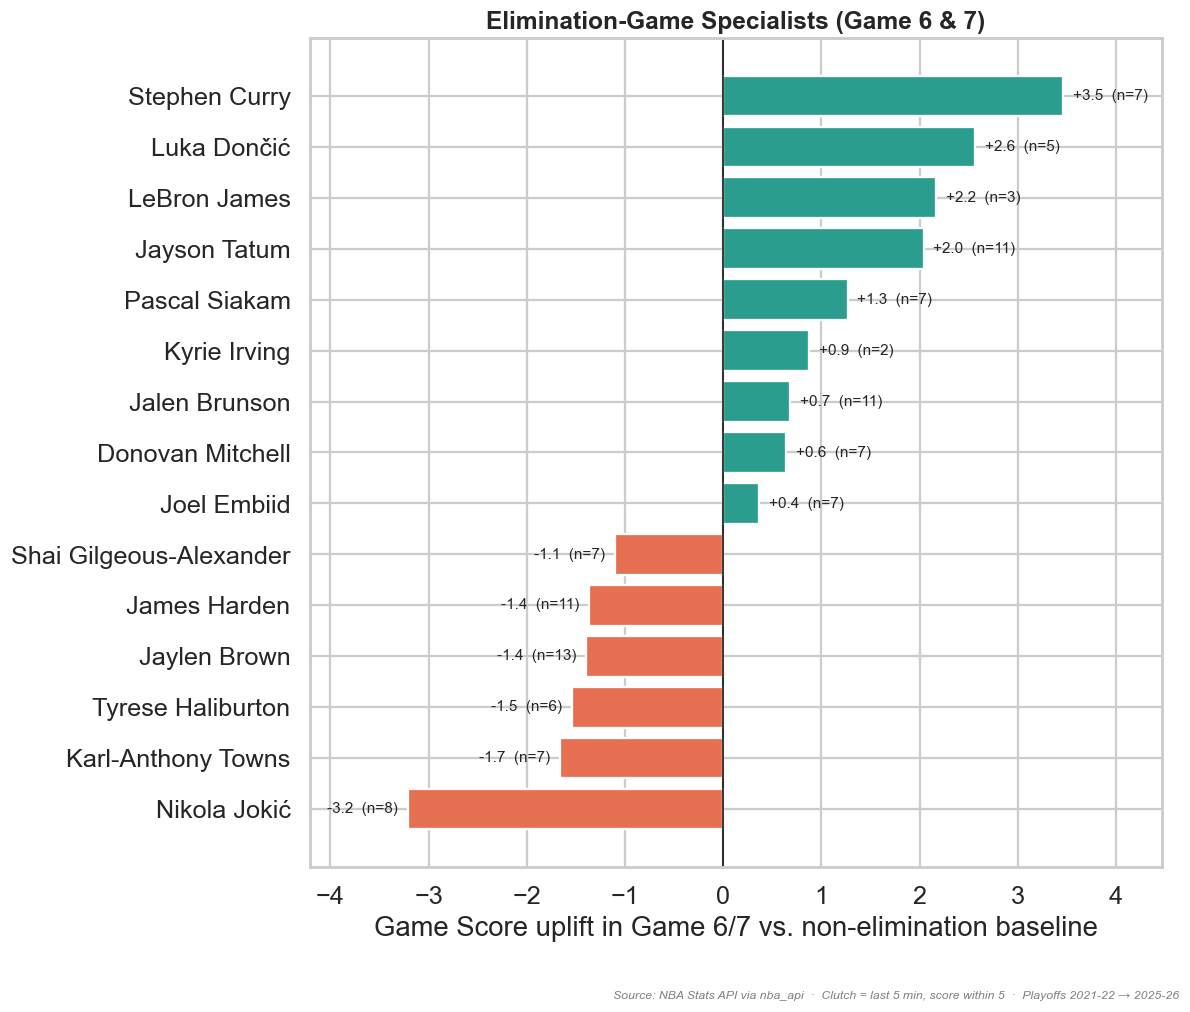

Full elimination-game leaderboard (top 20):


,PLAYER_NAME,TEAM,elim_games,non_elim_gmsc,elim_gmsc,elim_delta
2,Stephen Curry,GSW,7,19.39,22.86,3.46
13,Luka Dončić,LAL,5,22.19,24.76,2.57
6,LeBron James,LAL,3,20.93,23.10,2.17
3,Jayson Tatum,BOS,11,19.67,21.71,2.04
11,Pascal Siakam,IND,7,16.96,18.23,1.27
14,Kyrie Irving,DAL,2,15.88,16.75,0.88
0,Jalen Brunson,NYK,11,19.34,20.02,0.68
8,Donovan Mitchell,CLE,7,17.90,18.54,0.64
17,Joel Embiid,PHI,7,18.94,19.30,0.36
1,Shai Gilgeous-Alexander,OKC,7,23.20,22.10,-1.10


In [10]:
MIN_ELIM_GAMES = 2
elim_rank = (df[df["elim_games"] >= MIN_ELIM_GAMES]
             .dropna(subset=["elim_delta"])
             .sort_values("elim_delta", ascending=False))

top_elim = elim_rank.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 9))
bar_colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in top_elim["elim_delta"]]
ax.barh(top_elim["PLAYER_NAME"], top_elim["elim_delta"], color=bar_colors)
for y, (val, n) in enumerate(zip(top_elim["elim_delta"], top_elim["elim_games"])):
    ax.text(val + (0.1 if val >= 0 else -0.1), y, f"{val:+.1f}  (n={n})",
            va="center", ha="left" if val >= 0 else "right", fontsize=10)

ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Game Score uplift in Game 6/7 vs. non-elimination baseline")
ax.set_title("Elimination-Game Specialists (Game 6 & 7)",
             fontsize=16, weight="bold")
ax.margins(x=0.15)
stamp(fig)
plt.tight_layout()
plt.show()

print("Full elimination-game leaderboard (top 20):")
elim_rank[["PLAYER_NAME", "TEAM", "elim_games", "non_elim_gmsc",
           "elim_gmsc", "elim_delta"]].head(20).round(2)

## Cell 9 — Visualization 4: Most consistent clutch performers

**What it shows.** Who you can *count on* night to night — the players whose scoring
varies the least from game to game across the playoffs.

**How to read it.** Bars are sorted with the **most consistent player at the top**.
The value on the axis is the **consistency score** (higher = steadier), and each
label also shows the raw **CV** it's derived from (lower CV = steadier). Color is a
cosmetic gradient (*crest*) tracking rank.

**The stat behind it.** We start from the **coefficient of variation**,
`CV = std(points) / mean(points)` across all of a player's playoff games. CV is
*scale-free* — dividing by the mean means a 25-PPG star and an 8-PPG role player are
compared on equal footing, rather than the high scorer automatically looking more
volatile. Because lower CV is better but bars read more naturally when "higher =
better," we convert it to `consistency = 1 / (1 + CV)`, which maps onto a tidy 0-1
scale (CV 0 → 1.0; larger CV → toward 0). We require **≥ 10 playoff games** so the
variance estimate is stable.

**What to look for.** High bars = dependable, low-variance scorers. Two caveats
worth keeping in mind: consistency is measured on **overall playoff scoring**, not
clutch-only (clutch-minute box scores per game aren't exposed at scale), and a very
*low-usage* player can look "consistent" simply by scoring a steady handful each
night — so cross-reference with usage and PPG before reading too much into a name.

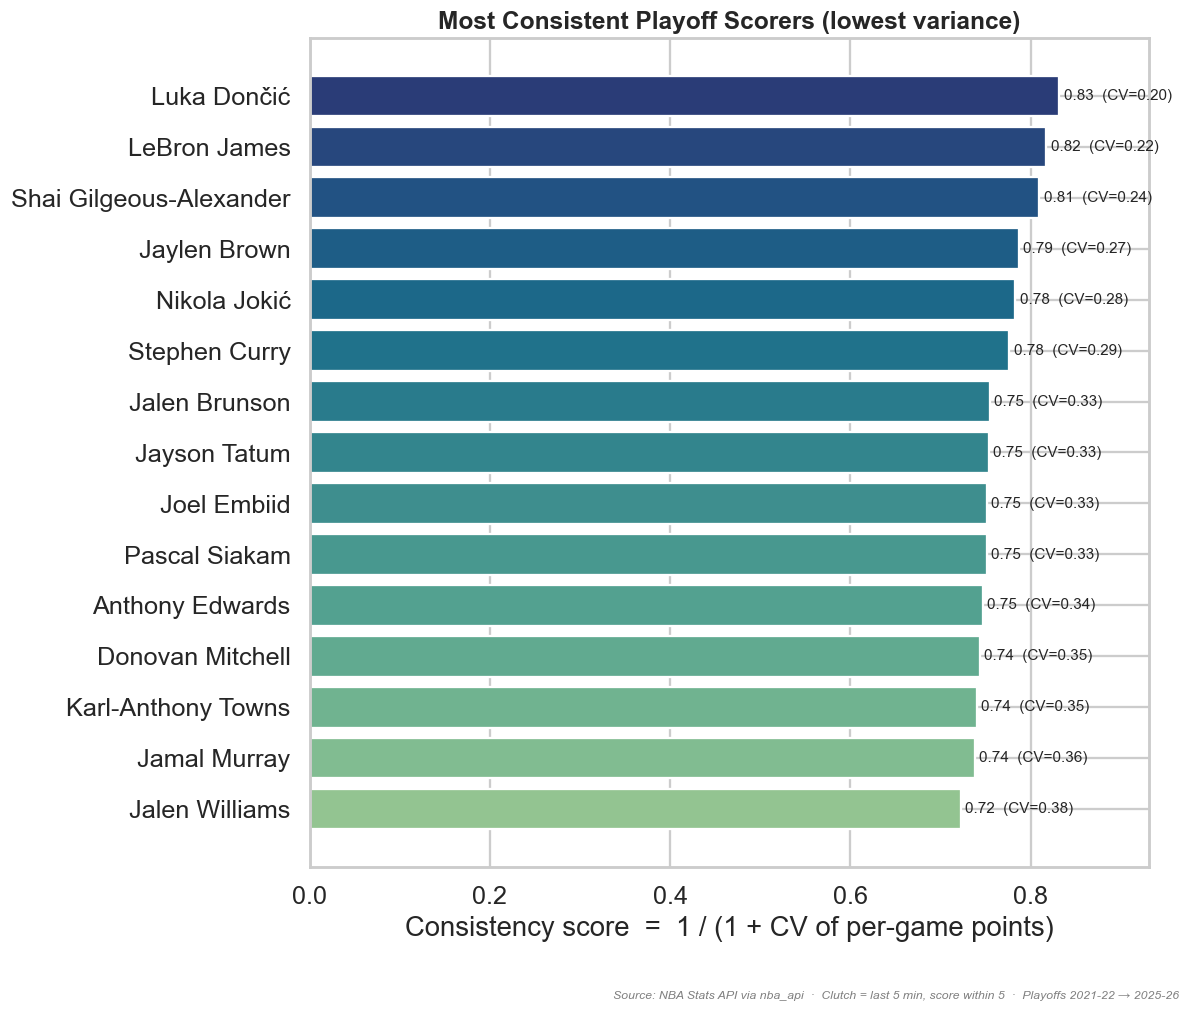

In [11]:
MIN_PO_GAMES = 10
cons = (df[(df["po_games"] >= MIN_PO_GAMES) & df["consistency"].notna()]
        .sort_values("consistency", ascending=False)
        .head(15).iloc[::-1])

fig, ax = plt.subplots(figsize=(11, 9))
colors = sns.color_palette("crest", len(cons))
ax.barh(cons["PLAYER_NAME"], cons["consistency"], color=colors)
for y, (c, cv) in enumerate(zip(cons["consistency"], cons["pts_cv"])):
    ax.text(c + 0.005, y, f"{c:.2f}  (CV={cv:.2f})", va="center", fontsize=10)

ax.set_xlabel("Consistency score  =  1 / (1 + CV of per-game points)")
ax.set_title("Most Consistent Playoff Scorers (lowest variance)",
             fontsize=16, weight="bold")
ax.margins(x=0.12)
stamp(fig)
plt.tight_layout()
plt.show()

## Cell 10 — Visualization 5: Year-over-year clutch trend (top 10)

**What it shows.** Whether the top-10 players' clutch level is *rising, fading, or
steady* — one line per player, tracked across the five playoff runs.

**How to read it.** The **x-axis is the playoff season** (chronological,
left→right) and the **y-axis is a per-season clutch score (0-100)**. Each colored
line is one player (see legend). A **rising line** = trending up / entering their
clutch prime; a **falling line** = declining clutch output; a **flat line** =
remarkably steady. A **gap or missing point** means that player's team didn't make
the playoffs (or didn't log clutch minutes) that year — not a zero.

**The stat behind it.** This score is computed *per player-season*, not from the
career composite, so it can move year to year. It blends the metrics that exist at
the single-season level — TS% (30%), +/- (25%), usage (20%), win-rate (15%), clutch
PPG (10%) — each percentile-normalized across *all* player-seasons in the dataset.
Elimination uplift and consistency are inherently career-level (they need a
multi-game/multi-season sample), so they're **excluded here** — meaning this
trend line and the headline composite use slightly different ingredients by design.

**What to look for.** Crossovers (one player overtaking another), a player peaking
in a title run, or league-wide dips/rises in a given year. Single-season clutch
samples are small, so expect some jagged year-to-year movement — focus on the
*direction* of the trend rather than one-season blips.

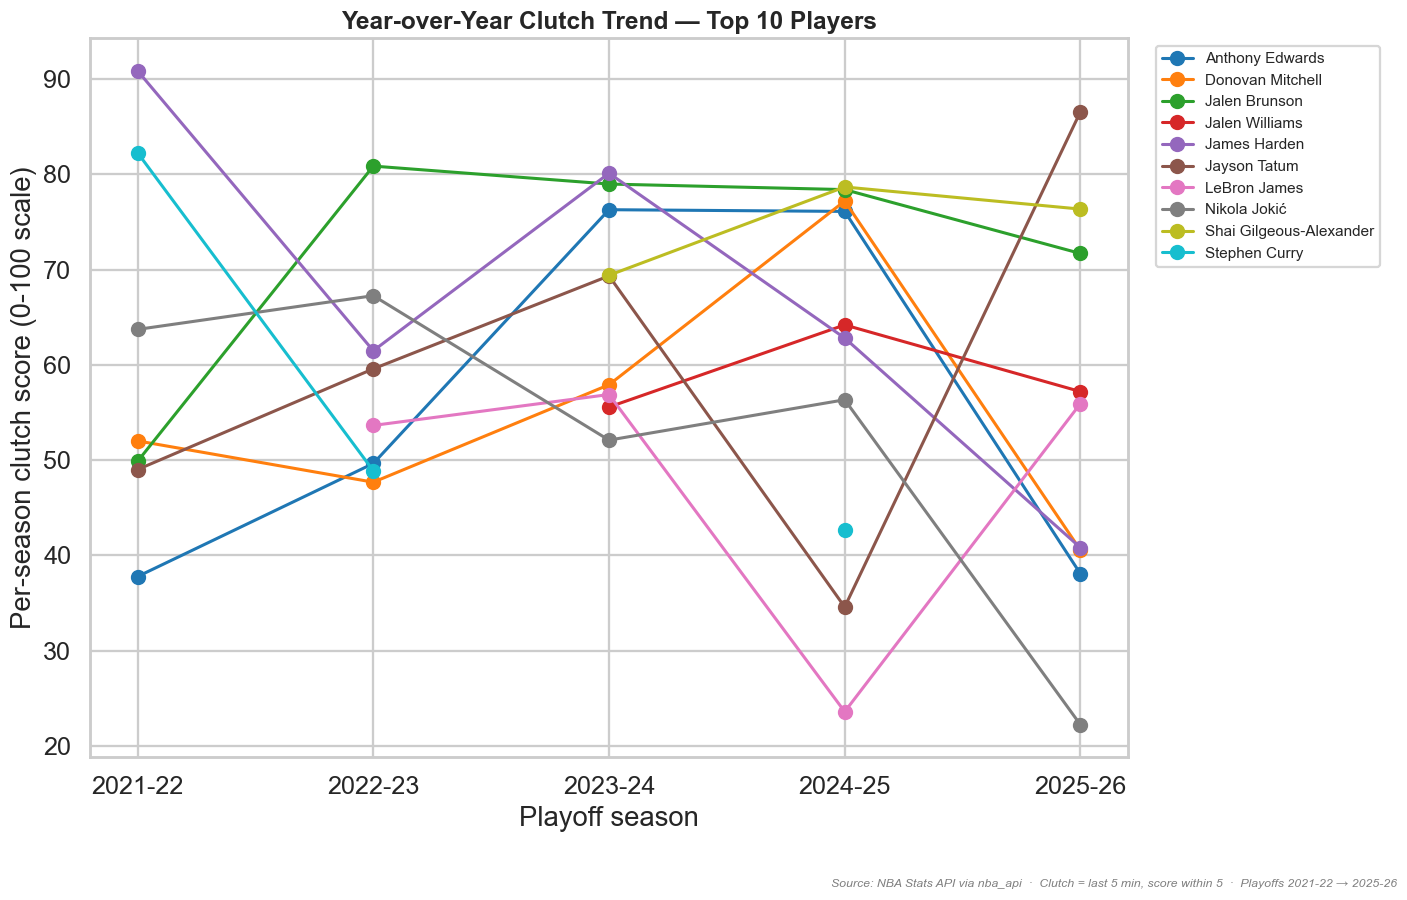

In [12]:
# Build a per-player-per-season clutch score from the season-level clutch table.
ps = clutch.copy()
ps["win_rate_season"] = ps["W"] / (ps["W"] + ps["L"]).replace(0, np.nan)

season_metric_cols = {
    "TS_PCT": "ts",
    "PLUS_MINUS": "pm",
    "USG_PCT": "usg",
    "win_rate_season": "win",
    "PTS": "ppg",
}
for col in season_metric_cols:
    ps[f"n_{season_metric_cols[col]}"] = normalize_100(ps[col])

# Re-weight the available season metrics (renormalize the subset of weights).
season_weights = {"ts": 0.30, "pm": 0.25, "usg": 0.20, "win": 0.15, "ppg": 0.10}
ps["season_clutch_score"] = sum(ps[f"n_{k}"] * w for k, w in season_weights.items())

top10_ids = df.head(10)["PLAYER_ID"].tolist()
trend = ps[ps["PLAYER_ID"].isin(top10_ids)].copy()
name_map = df.set_index("PLAYER_ID")["PLAYER_NAME"].to_dict()
trend["PLAYER_NAME"] = trend["PLAYER_ID"].map(name_map)

pivot = trend.pivot_table(index="SEASON", columns="PLAYER_NAME",
                          values="season_clutch_score", aggfunc="mean")
pivot = pivot.reindex(sorted(pivot.index))  # chronological seasons

fig, ax = plt.subplots(figsize=(13, 8))
palette = sns.color_palette("tab10", len(pivot.columns))
for color, player in zip(palette, pivot.columns):
    ax.plot(pivot.index, pivot[player], marker="o", lw=2, label=player, color=color)

ax.set_ylabel("Per-season clutch score (0-100 scale)")
ax.set_xlabel("Playoff season")
ax.set_title("Year-over-Year Clutch Trend — Top 10 Players",
             fontsize=16, weight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
stamp(fig)
plt.tight_layout()
plt.show()

## Cell 11 — Multi-model validation: don't trust a single index

A single hand-weighted composite is fragile: the weights are a judgment call, and
the input metrics are **correlated** (efficient scorers also tend to post good
+/-, etc.), so a weighted sum can double-count the same underlying signal. We
attack this with several models, each doing the job it's actually suited for:

**Structure / exploratory (unsupervised):**
- **PCA** — finds the dominant axes of variation in clutch play. *Note:* the first
  component typically captures a **volume/role** axis (usage & scoring) rather than
  pure quality, so we use it to *understand* the data, **not** to rank it (see the
  loadings below — this is exactly why PC1 disagrees with the quality ranking).
- **KMeans** — surfaces clutch *archetypes* (styles of player).

**Association (supervised):**
- **Regression** — asks *which* clutch skills track winning, with cross-validated R².

**Robustness ensemble (the actual trust check):** we re-score quality **three
ways that differ only in normalization & weighting** —
1. percentile composite (Cell 5 weights),
2. equal-weight percentile (naive baseline), and
3. winsorized **z-score** weighted (same weights, different, magnitude-aware scaling).

If these three agree (high **Spearman** correlation), the leaderboard isn't an
artifact of one normalization or weighting choice — and *that* is what lets us
trust the result. All model inputs are standardized first (`StandardScaler`).

**How to read the PCA loadings chart below.** Each bar is one metric's *loading* on
the first principal component (PC1) — how strongly that metric points along the
data's single biggest axis of variation. Bars pointing the **same direction** move
together; bars pointing **opposite** directions trade off against each other. If you
see usage/PPG on one side and efficiency on the other, PC1 is describing a
*volume-vs-efficiency style axis* — which is why we keep PCA as an explanatory tool
and don't fold it into the quality ranking. The printed "% of variance" tells you
how much of the whole picture PC1 alone captures (the rest lives in PC2, PC3, …).

PC1 explains 42.3% of variance (first 3 PCs: [0.423 0.231 0.106]).


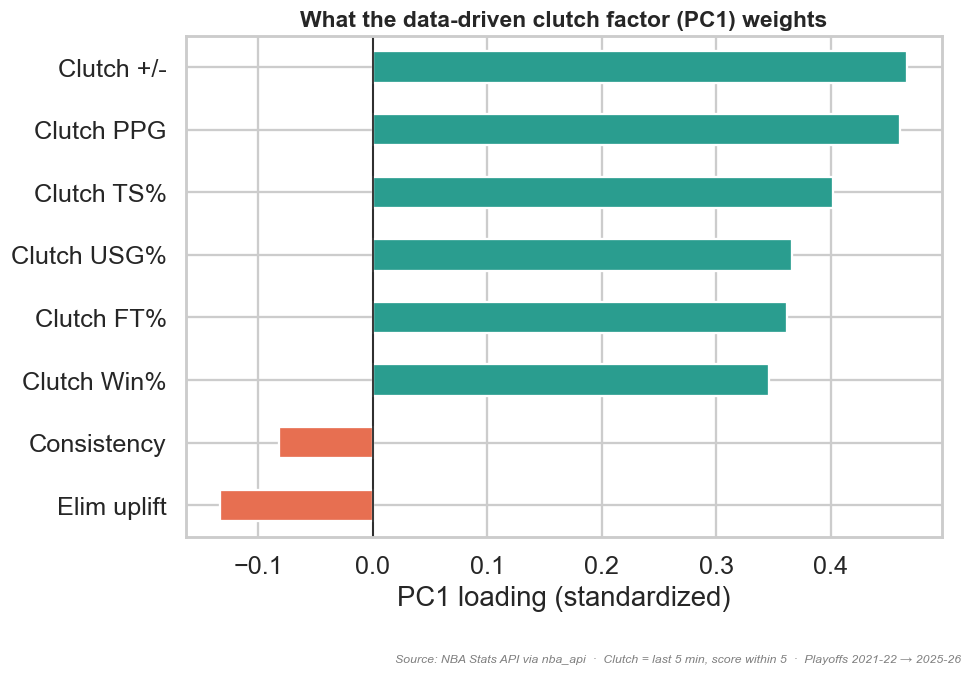

In [13]:
# Shared, standardized feature matrix on the same filtered player pool.
MODEL_FEATURES = {
    "clutch_ts": "Clutch TS%",
    "clutch_plus_minus": "Clutch +/-",
    "clutch_usg": "Clutch USG%",
    "clutch_ppg": "Clutch PPG",
    "clutch_ft_pct": "Clutch FT%",
    "win_rate_clutch": "Clutch Win%",
    "elim_delta_f": "Elim uplift",
    "consistency_f": "Consistency",
}
feat = df[list(MODEL_FEATURES)].copy()
feat = feat.fillna(feat.median())
scaler = StandardScaler()
X = scaler.fit_transform(feat)
feat_labels = list(MODEL_FEATURES.values())

# ---- Model 1: PCA -> data-driven clutch factor ----------------------------
pca = PCA(n_components=min(5, X.shape[1]), random_state=42)
pcs = pca.fit_transform(X)
pc1 = pcs[:, 0]
# Orient PC1 so "higher = more clutch" by aligning its sign with the composite.
sign = 1.0 if np.corrcoef(pc1, df["composite_score"])[0, 1] >= 0 else -1.0
pc1 = pc1 * sign
df["pca_score"] = (pc1 - pc1.min()) / np.ptp(pc1) * 100.0

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance "
      f"(first 3 PCs: {pca.explained_variance_ratio_[:3].round(3)}).")

loadings = pd.Series(pca.components_[0] * sign, index=feat_labels).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
loadings.plot.barh(ax=ax, color=["#e76f51" if v < 0 else "#2a9d8f" for v in loadings])
ax.axvline(0, color="black", lw=1)
ax.set_title("What the data-driven clutch factor (PC1) weights", fontsize=15, weight="bold")
ax.set_xlabel("PC1 loading (standardized)")
stamp(fig)
plt.tight_layout()
plt.show()

### Clutch archetypes (KMeans)

**What it shows.** Natural *groupings* of clutch players — the algorithm finds
clusters of players with similar clutch profiles, which we interpret as **styles**
(e.g. high-usage shot-creators vs. efficient low-volume finishers).

**How it works.** KMeans groups players in the 8-dimensional standardized
clutch-metric space so that players within a cluster are as similar as possible. We
try *k* = 2…6 clusters and pick the *k* with the best **silhouette score** — a
0-to-1 measure of how cleanly separated the clusters are (higher = tighter,
better-separated groups). The printed **z-score profile** table is the key to
*naming* each cluster: each number is how many standard deviations that cluster sits
**above (+) or below (−) the league average** on a given metric — so a row that's
`+0.9 usage, +0.8 PPG, −0.3 TS%` reads as "high-volume but less efficient."

**How to read the scatter.** It re-uses the familiar **TS% (x) vs. +/- (y)** view,
but now **color = archetype** (one color per cluster) and **size = usage**. You're
looking for *where each style lives* on the efficiency/impact map — e.g. one color
clustering in the high-usage/lower-efficiency region, another in the
efficient/role-player region.

**What to look for.** Read the profile table first to label the clusters, then see
which star belongs to which style. Note that clusters are about *similarity of
style*, **not** quality — a player isn't "better" for being in a particular cluster,
just different in how they operate in the clutch.

Silhouette score by k: {2: 0.218, 3: 0.241, 4: 0.239, 5: 0.213, 6: 0.21} ->  best k = 3

Cluster z-score profiles (mean standardized value per trait):
         Clutch TS%  Clutch +/-  Clutch USG%  Clutch PPG  Clutch FT%  Clutch Win%  Elim uplift  Consistency
cluster                                                                                                    
0             -0.98       -0.86        -0.32       -0.55       -0.58        -0.89         0.60         0.34
1              0.49        0.16        -0.30       -0.19        0.22         0.42        -0.76        -0.54
2              0.99        1.59         1.54        1.78        0.77         0.95         0.63         0.64


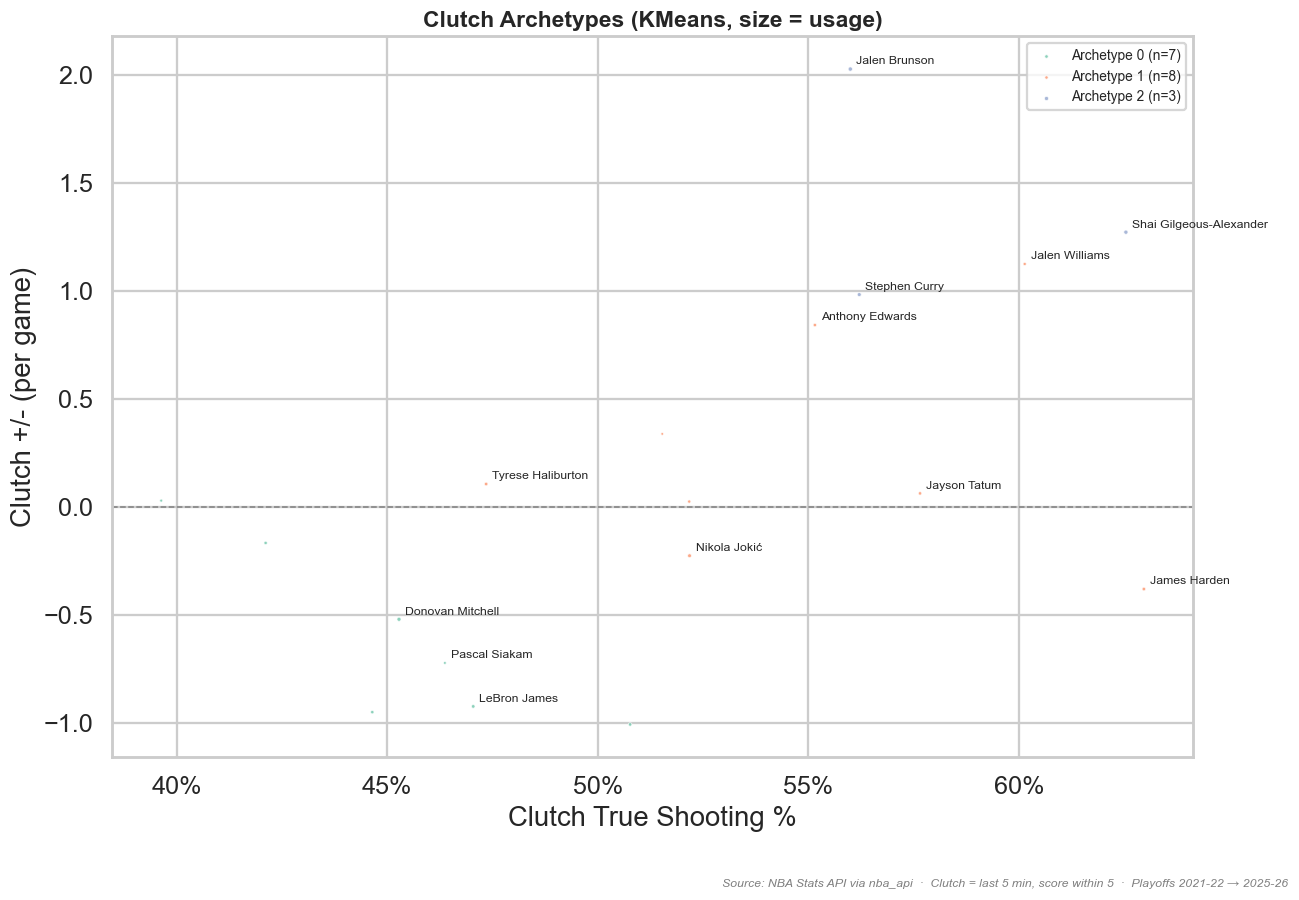

In [14]:
sil = {}
for k in range(2, 7):
    labels_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    sil[k] = silhouette_score(X, labels_k)
best_k = max(sil, key=sil.get)
print("Silhouette score by k:", {k: round(v, 3) for k, v in sil.items()},
      "->  best k =", best_k)

km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
df["cluster"] = km.labels_

# Standardized profile of each cluster (which traits each archetype over-indexes on).
profile = pd.DataFrame(X, columns=feat_labels)
profile["cluster"] = km.labels_
print("\nCluster z-score profiles (mean standardized value per trait):")
print(profile.groupby("cluster").mean().round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette("Set2", best_k)
for c in range(best_k):
    sub = df[df["cluster"] == c]
    ax.scatter(sub["clutch_ts"] * 100, sub["clutch_plus_minus"],
               s=(sub["clutch_usg"].fillna(sub["clutch_usg"].median())) * 18,
               color=palette[c], alpha=0.75, edgecolor="white",
               linewidth=0.6, label=f"Archetype {c} (n={len(sub)})")
for _, r in df.head(12).iterrows():
    ax.annotate(r["PLAYER_NAME"], (r["clutch_ts"] * 100, r["clutch_plus_minus"]),
                fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="grey", lw=1, ls="--")
ax.set_xlabel("Clutch True Shooting %")
ax.set_ylabel("Clutch +/- (per game)")
ax.set_title("Clutch Archetypes (KMeans, size = usage)", fontsize=15, weight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(loc="best", fontsize=9)
stamp(fig)
plt.tight_layout()
plt.show()

### Which clutch skills actually track winning? (regression)

**What it shows.** Of all the clutch skills we measure, which ones are most
associated with *winning* clutch games — and how much of winning the box score can
explain at all.

**How it works.** We fit a **linear regression** with clutch win rate as the target
and the other clutch skills as standardized predictors (win rate is excluded from
its own prediction). Two outputs matter:
- **Cross-validated R²** (printed) — trained and tested on different folds of
  players via 5-fold CV, so it reflects *generalization*, not memorization. R²
  ranges from 0 (explains nothing) to 1 (explains everything); ~0.3 means the
  individual clutch stats account for roughly a third of the variation in who wins.
- **Standardized coefficients** (the chart) — because every predictor is on the same
  scale, bar *length* is comparable importance. **Green (positive)** = more of this
  skill is associated with a higher clutch win rate; **red (negative)** = associated
  with lower. Each unit is "standard deviations of win rate per standard deviation
  of the skill."

**How to read the chart.** Longest green bars = the skills most tied to winning;
red bars = skills that (in this sample, holding others constant) trend the other
way. The 0 line is "no association."

**The honest caveat.** This is **association, not causation.** Win rate is heavily
**team-driven** — a great teammate or an easy bracket lifts it independent of the
individual — so a modest R² is the *expected, useful* result: it quantifies how much
clutch winning is *not* captured by one player's box score. That's exactly why we
don't use win rate alone to crown anyone (see *Limitations*).

5-fold CV R^2 (predicting clutch win rate): -1.488  (+/- 1.975)
A modest/low R^2 is expected -- winning is largely team-driven.



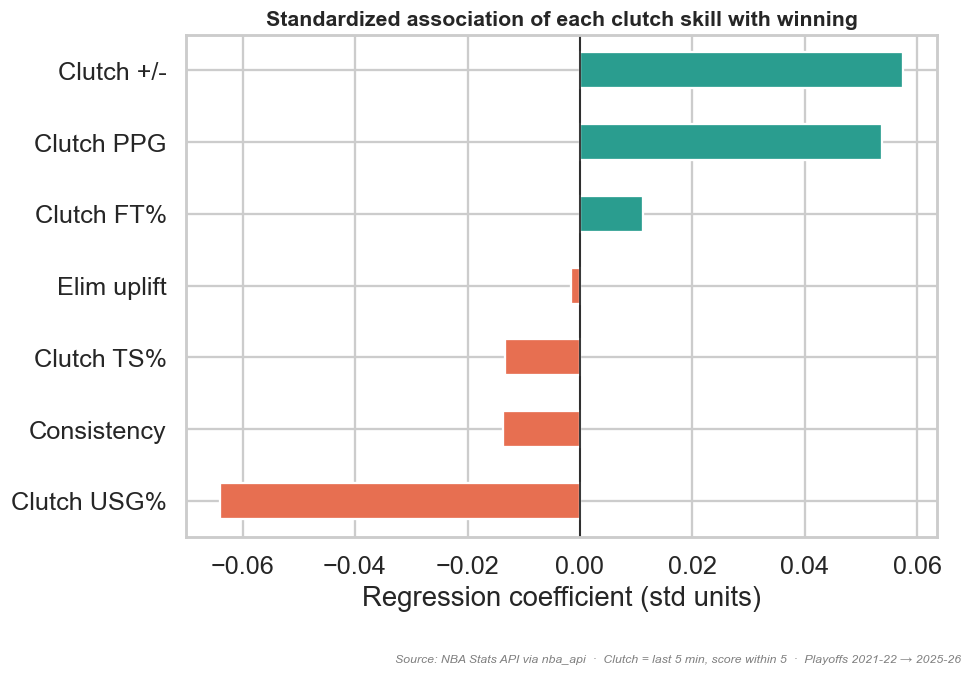

In [15]:
reg_cols = [c for c in MODEL_FEATURES if c != "win_rate_clutch"]
Xr = StandardScaler().fit_transform(df[reg_cols].fillna(df[reg_cols].median()))
yr = df["win_rate_clutch"].fillna(df["win_rate_clutch"].median()).values

lr = LinearRegression().fit(Xr, yr)
cv = cross_val_score(lr, Xr, yr, cv=KFold(5, shuffle=True, random_state=42), scoring="r2")
print(f"5-fold CV R^2 (predicting clutch win rate): {cv.mean():.3f}  (+/- {cv.std():.3f})")
print("A modest/low R^2 is expected -- winning is largely team-driven.\n")

coef = pd.Series(lr.coef_, index=[MODEL_FEATURES[c] for c in reg_cols]).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
coef.plot.barh(ax=ax, color=["#e76f51" if v < 0 else "#2a9d8f" for v in coef])
ax.axvline(0, color="black", lw=1)
ax.set_title("Standardized association of each clutch skill with winning",
             fontsize=14, weight="bold")
ax.set_xlabel("Regression coefficient (std units)")
stamp(fig)
plt.tight_layout()
plt.show()

### Ensemble & method agreement

**What it shows.** *How much we can trust the ranking.* The three quality-scoring
methods (percentile composite, equal-weight, winsorized z-score) are combined into
an **ensemble rank** (the mean of each player's rank across the three), and the
heatmap reports how strongly the three methods agree.

**How to read the heatmap.** It's a correlation matrix: each cell is the
**Spearman rank correlation** between two methods, from 0 (no agreement on the
ordering) to 1 (identical ordering). The diagonal is always 1.0 (a method vs.
itself). **Darker / higher off-diagonal cells = the methods rank players almost the
same way.** Spearman is used (not Pearson) because we care about *order* — who's
ahead of whom — not the exact score values.

**Why it matters.** If three differently-built scores still produce nearly the same
ordering, the leaderboard is **robust** — it isn't an accident of one normalization
or one set of weights. If they *disagreed*, that would be a warning that the result
hinges on arbitrary choices. The printed **ensemble top 15** lists the players whose
high placement survives all three methods, and the **Ensemble** column in the final
table is the single number least sensitive to those modeling choices.

**What to look for.** Off-diagonal values near 0.85-1.0 = strong, reassuring
agreement. Also scan the ensemble list for any name that the composite rated highly
but the ensemble pulls *down* — that's a player whose ranking depended on the
specific weighting, and who deserves a closer look.

Spearman rank correlation between quality-scoring methods:
              Composite  Equal-weight  Winsor-z
Composite         1.000         0.884     0.936
Equal-weight      0.884         1.000     0.915
Winsor-z          0.936         0.915     1.000
(High agreement => the ranking is robust to normalization/weighting choices.)


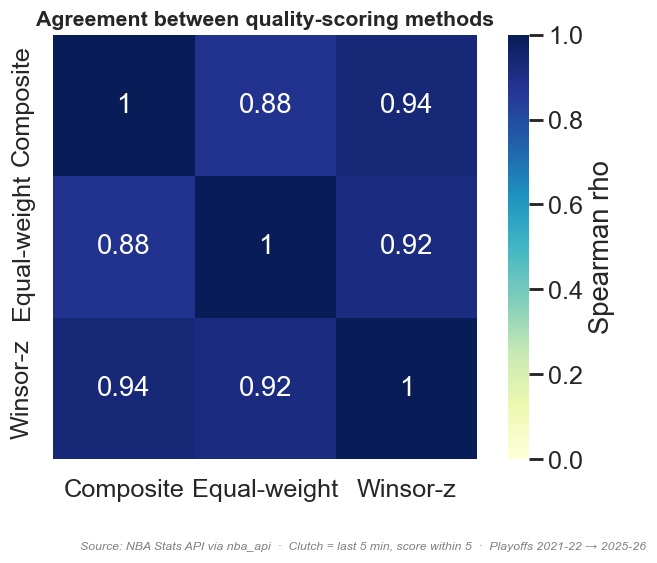


Ensemble top 15 (robust to normalization & weighting choice):
            PLAYER_NAME TEAM  composite_score  equal_score  zweight_score  ensemble_score
Shai Gilgeous-Alexander  OKC             61.2         86.9            1.3           100.0
          Jalen Brunson  NYK             82.9         84.9            1.1            95.9
          Stephen Curry  GSW             56.7         84.5            1.1            91.8
           Jayson Tatum  BOS             55.7         63.1            0.3            83.7
           James Harden  CLE             46.2         53.6            0.2            73.5
           Nikola Jokić  DEN             46.1         54.8            0.0            73.5
           LeBron James  LAL             38.3         51.6           -0.0            59.2
         Jalen Williams  OKC             34.7         52.4           -0.1            53.1
       Donovan Mitchell  CLE             37.0         46.0           -0.0            53.1
        Anthony Edwards  MIN         

In [16]:
# Quality scoring #2: equal-weight percentile baseline.
equal_cols = ["n_ppg", "n_ts", "n_plus_minus", "n_usage", "n_win_rate",
              "n_elimination", "n_consistency"]
df["equal_score"] = df[equal_cols].mean(axis=1)


# Quality scoring #3: winsorized z-score with the Cell-5 weights (a different,
# magnitude-aware normalization than the percentile composite).
def robust_z(series):
    s = series.astype(float).fillna(series.median())
    lo, hi = s.quantile(0.05), s.quantile(0.95)
    s = s.clip(lo, hi)
    sd = s.std(ddof=0)
    return (s - s.mean()) / sd if sd > 0 else pd.Series(0.0, index=s.index)


z_weight_map = {
    "clutch_ppg": WEIGHTS["ppg"],
    "clutch_ts": WEIGHTS["ts"],
    "elim_delta_f": WEIGHTS["elimination"],
    "clutch_usg": WEIGHTS["usage"],
    "clutch_plus_minus": WEIGHTS["plus_minus"],
    "consistency_f": WEIGHTS["consistency"],
    "win_rate_clutch": WEIGHTS["win_rate"],
}
df["zweight_score"] = sum(robust_z(df[col]) * w for col, w in z_weight_map.items())

# Three quality rankings that differ ONLY in normalization & weighting.
methods = {"Composite": "composite_score", "Equal-weight": "equal_score", "Winsor-z": "zweight_score"}
rank_df = pd.DataFrame({name: df[col].rank(ascending=False) for name, col in methods.items()})
df["ensemble_rank"] = rank_df.mean(axis=1)
df["ensemble_score"] = (df["ensemble_rank"].max() - df["ensemble_rank"] + 1)
df["ensemble_score"] = df["ensemble_score"] / df["ensemble_score"].max() * 100.0

# Spearman agreement between the three quality methods.
corr = pd.DataFrame(index=list(methods), columns=list(methods), dtype=float)
for a in methods:
    for b in methods:
        corr.loc[a, b] = spearmanr(df[methods[a]], df[methods[b]]).correlation
print("Spearman rank correlation between quality-scoring methods:")
print(corr.round(3).to_string())
print("(High agreement => the ranking is robust to normalization/weighting choices.)")

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr.astype(float), annot=True, cmap="YlGnBu", vmin=0, vmax=1,
            square=True, ax=ax, cbar_kws={"label": "Spearman rho"})
ax.set_title("Agreement between quality-scoring methods", fontsize=14, weight="bold")
stamp(fig)
plt.tight_layout()
plt.show()

print("\nEnsemble top 15 (robust to normalization & weighting choice):")
print(df.sort_values("ensemble_rank")[
    ["PLAYER_NAME", "TEAM", "composite_score", "equal_score", "zweight_score",
     "ensemble_score"]].head(15).round(1).to_string(index=False))

## Cell 15 — Limitations, bias & how they're mitigated

Reading the leaderboard responsibly means knowing where it can mislead:

| Bias / limitation | Effect | Mitigation in this notebook |
|---|---|---|
| **Eligibility cutoff is binary** | A team's clear #3 who outplayed the #2 is excluded; the 2nd star on a weak team is included over a great team's 3rd option. | `STARS_PER_TEAM` and the usage/scoring `USG_SCORING_BLEND` are tunable in Cell 1; per-season eligibility means a player only counts in the years he led. |
| **Team-quality confound** | Clutch *win rate* and *+/-* reward stars on good teams regardless of individual play. | **De-weighted on purpose** for this model (+/- 10%, win-rate 5%); delivery metrics (PPG, TS%, usage, elimination) carry 75%; the regression confirms winning is largely team-driven (modest R²). |
| **Volume vs. opportunity** | Stars on deep runs accumulate more clutch minutes and more Game 6/7s. | All scoring is **rate-based**; the sample multiplier is **capped** at `SAMPLE_FULL_CONFIDENCE`, so accumulation can't buy rank past the cap. |
| **Small-sample volatility** | A few clutch possessions can spike TS% or +/-. | 50-minute floor, √ capped multiplier, and **percentile** (not min-max) normalization within the star pool. |
| **Correlated inputs** | A weighted sum double-counts overlapping signals. | Cross-checked with PCA, an equal-weight baseline, and a winsorized-z variant; ensemble + Spearman agreement. |
| **Elimination = full-game, not clutch-only** | G6/7 Game Score reflects the whole game, not just clutch minutes. | Stated explicitly; G6/7 chosen as the highest-leverage proxy available at scale. |
| **Consistency = overall playoff scoring CV** | Not strictly clutch-only. | Documented; capped at a 10% weight. |
| **No opponent/role adjustment** | Defensive difficulty isn't modeled. | Out of scope; noted as future work (e.g. opponent-adjusted clutch +/-). |

**Bottom line:** this is now a **superstar-delivery** ranking — it asks which #1/#2
option produces efficiently under pressure, not which role player is quietly
efficient. Lean on the **ensemble** column when you want the result least sensitive
to any single modeling choice.

## Final — Top 10 Clutch Players summary table

**What it shows.** The complete picture for the top 10 in one place — the headline
ranking plus every underlying metric that fed it, so a reader can see *why* each
player ranks where they do.

**How to read the columns.**
- **Clutch Score** — the domain-weighted composite (0-100); the **green gradient**
  makes the spread easy to scan.
- **Ensemble** — the robustness-checked score averaged across the three methods
  (0-100); the **blue gradient** flags it. When Clutch Score and Ensemble disagree
  for a player, their ranking is sensitive to the weighting choice — trust the
  Ensemble more.
- **Clutch PPG / TS% / USG% / +/- / FT%** — raw clutch production: scoring volume,
  efficiency, offensive load, on-court impact, and free-throw reliability.
- **Clutch Win%** — win rate in games where they logged clutch minutes (team-influenced).
- **Elim ΔGmSc** — Game 6/7 uplift vs. their non-elimination baseline (+ = rises in
  elimination games).
- **Clutch Min** — total clutch minutes = the sample size behind everything; bigger
  = more reliable.

**What to look for.** A balanced row (strong across most columns) is the mark of a
true two-way clutch performer; a player propped up by one or two columns is a
specialist. Cross-check **Clutch Min** before over-reading any single line — and
prefer the **Ensemble** column for the most defensible ordering.

In [17]:
summary_cols = {
    "rank": "Rank",
    "PLAYER_NAME": "Player",
    "TEAM": "Team",
    "composite_score": "Clutch Score",
    "ensemble_score": "Ensemble",
    "clutch_ppg": "Clutch PPG",
    "clutch_ts": "Clutch TS%",
    "clutch_usg": "Clutch USG%",
    "clutch_plus_minus": "Clutch +/-",
    "clutch_ft_pct": "Clutch FT%",
    "win_rate_clutch": "Clutch Win%",
    "elim_delta": "Elim ΔGmSc",
    "clutch_min_total": "Clutch Min",
}

top10_tbl = df.head(10)[list(summary_cols.keys())].rename(columns=summary_cols).copy()

# Convert fractional rate stats to percentages for display.
# (TS%, FT%, Win% AND USG% are all stored as fractions, e.g. 0.464 = 46.4%.)
for c in ["Clutch TS%", "Clutch FT%", "Clutch Win%", "Clutch USG%"]:
    top10_tbl[c] = top10_tbl[c] * 100

styled = (top10_tbl.style
          .hide(axis="index")
          .format({
              "Clutch Score": "{:.1f}", "Ensemble": "{:.1f}", "Clutch PPG": "{:.1f}",
              "Clutch TS%": "{:.1f}%", "Clutch USG%": "{:.1f}%",
              "Clutch +/-": "{:+.1f}", "Clutch FT%": "{:.1f}%",
              "Clutch Win%": "{:.1f}%", "Elim ΔGmSc": "{:+.1f}",
              "Clutch Min": "{:.0f}",
          })
          .background_gradient(subset=["Clutch Score"], cmap="YlGn")
          .background_gradient(subset=["Ensemble"], cmap="Blues")
          .set_caption("Top 10 Clutch Players — NBA Playoffs 2021-22 → 2025-26")
          .set_table_styles([
              {"selector": "caption",
               "props": [("font-size", "15px"), ("font-weight", "bold"),
                         ("padding", "8px")]},
              {"selector": "th",
               "props": [("background-color", "#222"), ("color", "white"),
                         ("text-align", "center")]},
              {"selector": "td", "props": [("text-align", "center")]},
          ]))
styled

Rank,Player,Team,Clutch Score,Ensemble,Clutch PPG,Clutch TS%,Clutch USG%,Clutch +/-,Clutch FT%,Clutch Win%,Elim ΔGmSc,Clutch Min
1,Jalen Brunson,NYK,82.9,95.9,4.3,56.0%,44.5%,+2.0,79.2%,62.5%,+0.7,149
2,Shai Gilgeous-Alexander,OKC,61.2,100.0,4.7,62.5%,42.0%,+1.3,96.3%,61.1%,-1.1,76
3,Stephen Curry,GSW,56.7,91.8,3.9,56.2%,38.6%,+1.0,91.0%,61.1%,+3.5,66
4,Jayson Tatum,BOS,55.7,83.7,2.2,57.7%,28.2%,+0.1,89.6%,57.1%,+2.0,118
5,James Harden,CLE,46.2,73.5,3.1,63.0%,31.4%,-0.4,70.6%,50.0%,-1.4,83
6,Nikola Jokić,DEN,46.1,73.5,2.8,52.2%,36.1%,-0.2,73.8%,54.8%,-3.2,108
7,LeBron James,LAL,38.3,59.2,2.3,47.0%,31.5%,-0.9,81.2%,35.3%,+2.2,71
8,Anthony Edwards,MIN,37.4,51.0,2.4,55.2%,29.2%,+0.8,94.4%,53.8%,-3.5,87
9,Donovan Mitchell,CLE,37.0,53.1,3.1,45.3%,39.8%,-0.5,82.7%,35.0%,+0.6,74
10,Jalen Williams,OKC,34.7,53.1,3.0,60.1%,24.7%,+1.1,77.8%,56.2%,-4.9,69
